 MÉTODO IDW EN UN CUARTO 3D

Primero define las dimensiones del cuarto en metros.
X = largo del cuarto
Y = ancho del cuarto
Z = altura del cuarto



Ingresa el largo del cuarto en metros:  3
Ingresa el ancho del cuarto en metros:  4
Ingresa la altura del cuarto en metros:  3



Ahora define cuántos sensores de temperatura hay dentro del cuarto.


Ingresa el número de sensores:  4



Ahora ingresa la ubicación de cada sensor en metros.
Cada sensor debe estar dentro del cuarto.

--- Sensor 1 ---


...


---------------------------------------------------
SIGNIFICADO DE LA POTENCIA p EN IDW
---------------------------------------------------
p = 1  -> Interpolación más suave.
        Los sensores lejanos todavía influyen bastante.

p = 2  -> Interpolación equilibrada.
        Es la opción más común en IDW.

p = 3  -> Interpolación más local.
        Los sensores cercanos dominan mucho más el resultado.
        Los sensores lejanos casi no influyen.
---------------------------------------------------

Ahora ingresa el punto donde quieres estimar la temperatura.
Este punto también debe estar dentro del cuarto.


Ingresa X del punto de consulta, entre 0 y 3.0:  1.2
Ingresa Y del punto de consulta, entre 0 y 4.0:  2
Ingresa Z del punto de consulta, entre 0 y 3.0:  1



El radio de búsqueda define qué sensores se usarán.
Solo se usarán sensores cuya distancia al punto de consulta sea menor o igual al radio.



Ingresa el radio de búsqueda en metros:  1.6
Elige la potencia p para IDW (1, 2 o 3):  2



 RESULTADOS DE LA INTERPOLACIÓN IDW

Dimensiones del cuarto:
Largo X = 3.0 m
Ancho Y = 4.0 m
Altura Z = 3.0 m

Punto de consulta en metros: [1.2 2.  1. ]
Radio de búsqueda elegido: 1.6 m
Potencia elegida: p = 2
Número de sensores dentro del radio: 3

Temperatura estimada en el punto elegido: 37.07 °C

Sensores usados para calcular la interpolación:
Sensor 1: ubicación = [1.8 2.  1. ] m, temperatura = 36.00 °C, distancia = 0.60 m, peso = 2.7778
Sensor 2: ubicación = [2. 2. 2.] m, temperatura = 40.00 °C, distancia = 1.28 m, peso = 0.6098
Sensor 3: ubicación = [2. 3. 1.] m, temperatura = 39.00 °C, distancia = 1.28 m, peso = 0.6098


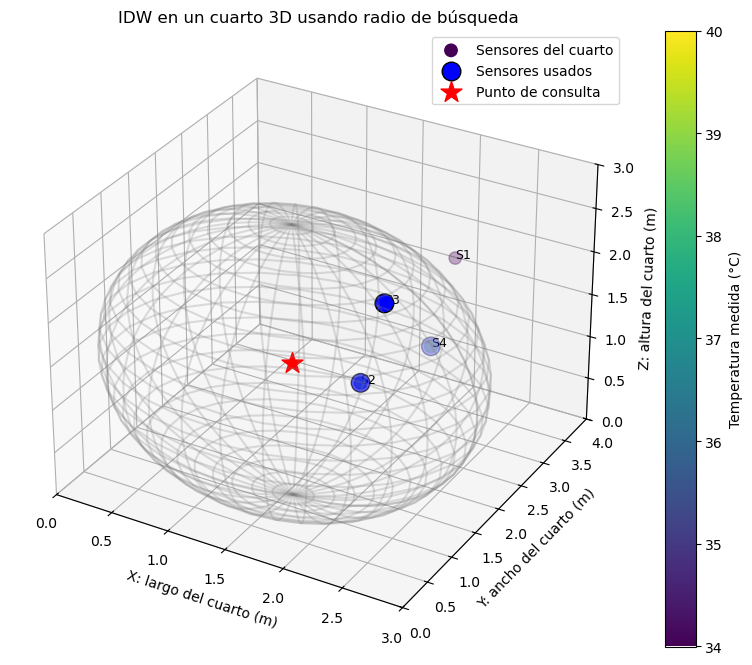

In [1]:
# ============================================================
# MÉTODO INVERSE DISTANCE WEIGHTING (IDW) EN UN CUARTO 3D
# El usuario define dimensiones, sensores, ubicaciones y potencia
# ============================================================

# Importamos numpy para hacer cálculos matemáticos
import numpy as np

# Importamos matplotlib para graficar en 3D
import matplotlib.pyplot as plt

# Importamos sys para poder detener el programa si hay un error importante
import sys


# ============================================================
# 1. PEDIR LAS DIMENSIONES DEL CUARTO
# ============================================================

print("===================================================")
print(" MÉTODO IDW EN UN CUARTO 3D")
print("===================================================")

print("\nPrimero define las dimensiones del cuarto en metros.")
print("X = largo del cuarto")
print("Y = ancho del cuarto")
print("Z = altura del cuarto")

# El usuario define el tamaño del cuarto
largo_cuarto = float(input("\nIngresa el largo del cuarto en metros: "))
ancho_cuarto = float(input("Ingresa el ancho del cuarto en metros: "))
alto_cuarto = float(input("Ingresa la altura del cuarto en metros: "))

# Verificamos que las dimensiones sean positivas
if largo_cuarto <= 0 or ancho_cuarto <= 0 or alto_cuarto <= 0:
    print("\nError: las dimensiones del cuarto deben ser mayores que cero.")
    sys.exit()


# ============================================================
# 2. PEDIR EL NÚMERO DE SENSORES
# ============================================================

print("\nAhora define cuántos sensores de temperatura hay dentro del cuarto.")

n_sensores = int(input("Ingresa el número de sensores: "))

# Verificamos que haya al menos un sensor
if n_sensores <= 0:
    print("\nError: debe existir al menos un sensor.")
    sys.exit()


# ============================================================
# 3. PEDIR UBICACIÓN Y TEMPERATURA DE CADA SENSOR
# ============================================================

print("\nAhora ingresa la ubicación de cada sensor en metros.")
print("Cada sensor debe estar dentro del cuarto.")

# Aquí guardaremos las ubicaciones de los sensores
lista_sensores = []

# Aquí guardaremos las temperaturas medidas por los sensores
lista_temperaturas = []

# Repetimos el proceso para cada sensor
for i in range(n_sensores):

    print(f"\n--- Sensor {i+1} ---")

    while True:
        # Pedimos la ubicación del sensor
        x = float(input(f"Ingresa X del sensor {i+1}, entre 0 y {largo_cuarto}: "))
        y = float(input(f"Ingresa Y del sensor {i+1}, entre 0 y {ancho_cuarto}: "))
        z = float(input(f"Ingresa Z del sensor {i+1}, entre 0 y {alto_cuarto}: "))

        # Verificamos si el sensor está dentro del cuarto
        if 0 <= x <= largo_cuarto and 0 <= y <= ancho_cuarto and 0 <= z <= alto_cuarto:
            break
        else:
            print("\nLa ubicación del sensor está fuera del cuarto.")
            print("Vuelve a ingresar las coordenadas.")

    # Pedimos la temperatura medida por ese sensor
    temperatura = float(input(f"Ingresa la temperatura medida por el sensor {i+1} en °C: "))

    # Guardamos la ubicación y la temperatura
    lista_sensores.append([x, y, z])
    lista_temperaturas.append(temperatura)


# Convertimos las listas a arreglos de numpy para poder hacer cálculos
sensores = np.array(lista_sensores)
temperaturas = np.array(lista_temperaturas)


# ============================================================
# 4. EXPLICAR AL USUARIO QUÉ SIGNIFICA LA POTENCIA p
# ============================================================

print("\n---------------------------------------------------")
print("SIGNIFICADO DE LA POTENCIA p EN IDW")
print("---------------------------------------------------")
print("p = 1  -> Interpolación más suave.")
print("        Los sensores lejanos todavía influyen bastante.")
print()
print("p = 2  -> Interpolación equilibrada.")
print("        Es la opción más común en IDW.")
print()
print("p = 3  -> Interpolación más local.")
print("        Los sensores cercanos dominan mucho más el resultado.")
print("        Los sensores lejanos casi no influyen.")
print("---------------------------------------------------")


# ============================================================
# 5. PEDIR EL PUNTO DONDE SE QUIERE INTERPOLAR
# ============================================================

print("\nAhora ingresa el punto donde quieres estimar la temperatura.")
print("Este punto también debe estar dentro del cuarto.")

while True:
    x_consulta = float(input(f"Ingresa X del punto de consulta, entre 0 y {largo_cuarto}: "))
    y_consulta = float(input(f"Ingresa Y del punto de consulta, entre 0 y {ancho_cuarto}: "))
    z_consulta = float(input(f"Ingresa Z del punto de consulta, entre 0 y {alto_cuarto}: "))

    # Verificamos que el punto esté dentro del cuarto
    if (
        0 <= x_consulta <= largo_cuarto and
        0 <= y_consulta <= ancho_cuarto and
        0 <= z_consulta <= alto_cuarto
    ):
        break
    else:
        print("\nEl punto de consulta está fuera del cuarto.")
        print("Vuelve a ingresar las coordenadas.")

# Guardamos el punto de consulta en formato [x, y, z]
punto_consulta = np.array([x_consulta, y_consulta, z_consulta])


# ============================================================
# 6. PEDIR RADIO DE BÚSQUEDA
# ============================================================

print("\nEl radio de búsqueda define qué sensores se usarán.")
print("Solo se usarán sensores cuya distancia al punto de consulta sea menor o igual al radio.")

radio_busqueda = float(input("\nIngresa el radio de búsqueda en metros: "))

# Verificamos que el radio sea positivo
if radio_busqueda <= 0:
    print("\nError: el radio de búsqueda debe ser mayor que cero.")
    sys.exit()


# ============================================================
# 7. PEDIR LA POTENCIA p
# ============================================================

potencia = int(input("Elige la potencia p para IDW (1, 2 o 3): "))

# Si el usuario elige una potencia diferente de 1, 2 o 3,
# el programa avisa que no es válida y se detiene.
if potencia not in [1, 2, 3]:
    print("\nLa potencia ingresada no es válida.")
    print("Solo puedes elegir p = 1, p = 2 o p = 3.")
    sys.exit()


# ============================================================
# 8. FUNCIÓN PARA CALCULAR IDW EN 3D CON RADIO DE BÚSQUEDA
# ============================================================

def idw_3d_con_radio(puntos, valores, punto, radio, p):
    """
    Esta función aplica el método Inverse Distance Weighting en 3D.

    Parámetros:
    puntos:
        Coordenadas de los sensores conocidos.
        Cada fila tiene la forma [x, y, z].

    valores:
        Temperaturas medidas en cada sensor.

    punto:
        Coordenada donde queremos estimar la temperatura.
        Tiene la forma [x, y, z].

    radio:
        Distancia máxima permitida.
        Solo se usan sensores dentro de este radio.

    p:
        Potencia del método IDW.
        Controla qué tanto pesan los sensores cercanos.

    Regresa:
    temperatura_estimada:
        Valor interpolado en el punto de consulta.

    vecinos:
        Sensores que están dentro del radio.

    valores_vecinos:
        Temperaturas de los sensores seleccionados.

    distancias_vecinos:
        Distancias de los sensores seleccionados al punto de consulta.

    pesos:
        Pesos calculados para cada sensor seleccionado.
    """

    # --------------------------------------------------------
    # Calcular la distancia en 3D entre el punto de consulta
    # y cada sensor conocido.
    #
    # Fórmula:
    # d = sqrt((x - xi)^2 + (y - yi)^2 + (z - zi)^2)
    # --------------------------------------------------------

    distancias = np.sqrt(
        (puntos[:, 0] - punto[0])**2 +
        (puntos[:, 1] - punto[1])**2 +
        (puntos[:, 2] - punto[2])**2
    )

    # --------------------------------------------------------
    # Seleccionar sensores dentro del radio de búsqueda.
    #
    # Si distancia <= radio, el sensor sí se usa.
    # Si distancia > radio, el sensor no se usa.
    # --------------------------------------------------------

    dentro_del_radio = distancias <= radio

    # Guardamos los sensores seleccionados
    vecinos = puntos[dentro_del_radio]

    # Guardamos las temperaturas de los sensores seleccionados
    valores_vecinos = valores[dentro_del_radio]

    # Guardamos las distancias de los sensores seleccionados
    distancias_vecinos = distancias[dentro_del_radio]

    # --------------------------------------------------------
    # Si no hay sensores dentro del radio, no se puede interpolar.
    # --------------------------------------------------------

    if len(vecinos) == 0:
        return None, vecinos, valores_vecinos, distancias_vecinos, None

    # --------------------------------------------------------
    # Si el punto de consulta coincide exactamente con un sensor,
    # entonces la distancia es cero.
    #
    # En ese caso no se usa la fórmula IDW, porque habría división
    # entre cero. Simplemente se devuelve la temperatura conocida.
    # --------------------------------------------------------

    if np.any(distancias_vecinos == 0):
        temperatura_exacta = valores_vecinos[distancias_vecinos == 0][0]
        return temperatura_exacta, vecinos, valores_vecinos, distancias_vecinos, None

    # --------------------------------------------------------
    # Calcular los pesos con IDW.
    #
    # Fórmula:
    # peso = 1 / distancia^p
    #
    # Un sensor cercano tiene distancia pequeña, por lo tanto
    # su peso será grande.
    #
    # Un sensor lejano tiene distancia grande, por lo tanto
    # su peso será pequeño.
    # --------------------------------------------------------

    pesos = 1 / (distancias_vecinos ** p)

    # --------------------------------------------------------
    # Calcular el promedio ponderado.
    #
    # Fórmula:
    # temperatura estimada =
    # suma(peso_i * temperatura_i) / suma(peso_i)
    # --------------------------------------------------------

    temperatura_estimada = np.sum(pesos * valores_vecinos) / np.sum(pesos)

    # Regresamos todos los resultados
    return temperatura_estimada, vecinos, valores_vecinos, distancias_vecinos, pesos


# ============================================================
# 9. APLICAR EL MÉTODO IDW
# ============================================================

temperatura_estimada, vecinos, valores_vecinos, distancias_vecinos, pesos = idw_3d_con_radio(
    sensores,
    temperaturas,
    punto_consulta,
    radio_busqueda,
    potencia
)


# ============================================================
# 10. MOSTRAR RESULTADOS EN PANTALLA
# ============================================================

print("\n===================================================")
print(" RESULTADOS DE LA INTERPOLACIÓN IDW")
print("===================================================")

print(f"\nDimensiones del cuarto:")
print(f"Largo X = {largo_cuarto} m")
print(f"Ancho Y = {ancho_cuarto} m")
print(f"Altura Z = {alto_cuarto} m")

print(f"\nPunto de consulta en metros: {punto_consulta}")
print(f"Radio de búsqueda elegido: {radio_busqueda} m")
print(f"Potencia elegida: p = {potencia}")
print(f"Número de sensores dentro del radio: {len(vecinos)}")

# Si no se encontró ningún sensor dentro del radio:
if temperatura_estimada is None:
    print("\nNo hay sensores dentro del radio seleccionado.")
    print("No se puede calcular la interpolación.")
    print("Prueba usando un radio de búsqueda más grande.")

# Si sí se pudo calcular la temperatura:
else:
    print(f"\nTemperatura estimada en el punto elegido: {temperatura_estimada:.2f} °C")

    print("\nSensores usados para calcular la interpolación:")

    # Recorremos cada sensor seleccionado para mostrar su información
    for i in range(len(vecinos)):

        # Si pesos es None, significa que el punto coincidió exactamente con un sensor
        if pesos is None:
            print(
                f"Sensor {i+1}: "
                f"ubicación = {vecinos[i]} m, "
                f"temperatura = {valores_vecinos[i]:.2f} °C, "
                f"distancia = {distancias_vecinos[i]:.2f} m"
            )

        # Si pesos existe, mostramos también el peso IDW
        else:
            print(
                f"Sensor {i+1}: "
                f"ubicación = {vecinos[i]} m, "
                f"temperatura = {valores_vecinos[i]:.2f} °C, "
                f"distancia = {distancias_vecinos[i]:.2f} m, "
                f"peso = {pesos[i]:.4f}"
            )


# ============================================================
# 11. GRAFICAR EL CUARTO, LOS SENSORES Y EL PUNTO DE CONSULTA
# ============================================================

# Creamos una figura para graficar en 3D
fig = plt.figure(figsize=(10, 8))

# Creamos un eje 3D
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# Graficar todos los sensores del cuarto
# ------------------------------------------------------------

grafica_sensores = ax.scatter(
    sensores[:, 0],       # Coordenada X
    sensores[:, 1],       # Coordenada Y
    sensores[:, 2],       # Coordenada Z
    c=temperaturas,       # Color según temperatura
    s=80,                 # Tamaño de los puntos
    label="Sensores del cuarto"
)

# ------------------------------------------------------------
# Graficar los sensores que sí quedaron dentro del radio
# ------------------------------------------------------------

if len(vecinos) > 0:
    ax.scatter(
        vecinos[:, 0],
        vecinos[:, 1],
        vecinos[:, 2],
        c="blue",
        s=180,
        edgecolors="black",
        label="Sensores usados"
    )

# ------------------------------------------------------------
# Graficar el punto donde se estimó la temperatura
# ------------------------------------------------------------

ax.scatter(
    punto_consulta[0],
    punto_consulta[1],
    punto_consulta[2],
    c="red",
    s=250,
    marker="*",
    label="Punto de consulta"
)

# ------------------------------------------------------------
# Escribir el nombre de cada sensor en la gráfica
# ------------------------------------------------------------

for i, sensor in enumerate(sensores):
    ax.text(
        sensor[0],
        sensor[1],
        sensor[2],
        f"S{i+1}",
        fontsize=9
    )

# ------------------------------------------------------------
# Dibujar una esfera transparente que representa el radio
# de búsqueda alrededor del punto de consulta.
# ------------------------------------------------------------

# Ángulos para construir la esfera
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)

# Coordenadas de la esfera
x_esfera = punto_consulta[0] + radio_busqueda * np.outer(np.cos(u), np.sin(v))
y_esfera = punto_consulta[1] + radio_busqueda * np.outer(np.sin(u), np.sin(v))
z_esfera = punto_consulta[2] + radio_busqueda * np.outer(np.ones(np.size(u)), np.cos(v))

# Graficamos la esfera como una malla
ax.plot_wireframe(
    x_esfera,
    y_esfera,
    z_esfera,
    color="gray",
    alpha=0.25
)

# ------------------------------------------------------------
# Configurar títulos y etiquetas
# ------------------------------------------------------------

ax.set_title("IDW en un cuarto 3D usando radio de búsqueda")
ax.set_xlabel("X: largo del cuarto (m)")
ax.set_ylabel("Y: ancho del cuarto (m)")
ax.set_zlabel("Z: altura del cuarto (m)")

# Límites de la gráfica según el tamaño real del cuarto
ax.set_xlim(0, largo_cuarto)
ax.set_ylim(0, ancho_cuarto)
ax.set_zlim(0, alto_cuarto)

# Barra de colores para interpretar la temperatura de los sensores
plt.colorbar(grafica_sensores, ax=ax, label="Temperatura medida (°C)")

# Mostrar leyenda
ax.legend()

# Mostrar gráfica final
plt.show()